# Mathematics for Data Science & Analytics (MDSA)
## Review 1 & 2: Comprehensive Advertising Sales Analysis

## 1. Problem Statement
The primary goal of this project is to analyze the relationship between various advertising channels (TV, Radio, and Newspaper) and their impact on total Sales. By examining this dataset, we aim to understand which advertising medium contributes most significantly to revenue and identify patterns that can help in optimizing future marketing budgets.

## 2. Objectives
1. To load and perform initial data inspection of the advertising dataset.
2. To identify and handle any missing or duplicate values to ensure data integrity.
3. To perform descriptive statistical analysis (Mean, Median, Standard Deviation) to understand data distribution.
4. To analyze categorical components and distributions within the data.
5. To derive professional observations that inform marketing strategy.

## 3. Import Libraries
We will start by importing the core libraries required for data manipulation and numerical analysis.

In [ ]:
import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Load Dataset
We use the `pd.read_csv()` function to load the data from the local directory into a pandas DataFrame object named `df`.

In [ ]:
df = pd.read_csv('/content/advertising.csv')
print("Dataset loaded.")

Dataset loaded.


## 5. Dataset Preview
We check the `shape` to see the number of rows and columns, and `head()` to see the first few records.

In [ ]:
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 6. Dataset Information
`df.info()` provides a summary of the columns, their data types, and non-null counts.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## 7. Missing Value Analysis
It is crucial to check for null values. If found, we will impute them using the median for numerical data and the mode for categorical data.

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

# Handling missing values if they exist
# Fill numerical columns with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill text columns with most common value (mode)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values handled (if any).")

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Missing values handled (if any).


## 9. Duplicate Analysis
Duplicates in a dataset can lead to biased statistical results and redundant information. We check for identical rows and remove them to ensure every observation is unique.

In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("Duplicate records removed.")

Number of duplicate rows: 0


## 10. Data Type Analysis
It is essential to verify that the features are stored in the correct format (float or int) so that mathematical calculations can be performed accurately.

In [ ]:
# 10. Data Type Analysis
display(df.dtypes)

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


## 11. Descriptive Statistics
The `describe()` function provides a comprehensive overview of the dataset's distribution, including central tendency (mean) and dispersion (standard deviation).

In [ ]:
# 11. Descriptive Statistics
display(df.describe())

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## 12. Mean Analysis
We calculate the average value for each advertising channel to see where the company is spending the most money on average.

In [ ]:
print(df.mean(numeric_only=True))

TV           147.0425
Radio         23.2640
Newspaper     30.5540
Sales         15.1305
dtype: float64


## 13. Median Analysis
We calculate the median to understand the central value of our data, which is less sensitive to outliers than the mean.

In [ ]:
print(df.median(numeric_only=True))

TV           149.75
Radio         22.90
Newspaper     25.75
Sales         16.00
dtype: float64


## 14. Standard Deviation Analysis
Standard deviation shows the spread of our data. A high value indicates that the spending varies significantly across different markets.

In [ ]:
print(df.std(numeric_only=True))

TV           85.854236
Radio        14.846809
Newspaper    21.778621
Sales         5.283892
dtype: float64


## 15. Categorical Analysis
Even though our main features are numerical, we check for categorical columns to ensure we haven't missed any qualitative labels.

In [ ]:
cat_columns = df.select_dtypes(include='object').columns
print("Categorical Columns:", list(cat_columns))

# Choosing columns if they existed to show value_counts
for col in cat_columns:
    print(f"\nCounts for {col}:")
    print(df[col].value_counts())

Categorical Columns: []


## 16. Professional Observations
Based on the analysis of the `advertising.csv` dataset, we have derived the following observations:

1. The dataset contains **200 observations** across 4 variables (TV, Radio, Newspaper, Sales).
2. **TV Advertising** has the highest mean spend of **147.04**, making it the primary marketing channel.
3. The average **Sales** across all markets is **15.13** units.
4. **Radio** has the lowest average budget of approximately **23.26**.
5. The **Standard Deviation for TV (85.85)** is the highest, indicating a very wide range of investment levels.
6. **Newspaper** spend varies significantly, with a maximum value of **114.0** and a minimum of only **0.3**.
7. The **Median Sales is 16.0**, which is very close to the mean (15.13), suggesting a relatively symmetric distribution for sales.
8. 50% of the markets have a **TV budget between 0.7 and 149.75**.
9. The **maximum Sales recorded is 27.0**, while the **minimum is 1.6**.
10. There are **0 missing values**, indicating a clean and complete dataset.
11. **Zero duplicates** were found, ensuring each row represents a unique market record.
12. **Radio budget** has a maximum of **49.6**, which is much lower than the peak TV budget of **296.4**.
13. The 75th percentile for **Newspaper is 45.1**, meaning only 25% of markets spend more than this amount on newspaper ads.
14. All columns are of **float64** data type, which is ideal for continuous regression analysis.
15. The **TV budget** is consistently the most volatile, with the largest gap between Min and Max values.

## 17. Conclusion
This Review-1 analysis provides a comprehensive overview of the Advertising dataset. We have successfully performed data cleaning, verified that there are no missing or duplicate records, and established the mathematical baseline for each advertising channel. The descriptive statistics highlight that TV is the most significant area of investment, while Radio and Newspaper receive relatively lower budgets. These findings serve as a foundation for the next phase of the project, where we will analyze correlations and build a model to predict sales based on these advertising inputs.

## 18. Correlation Analysis
Correlation measures the strength and direction of a linear relationship between two variables. This helps us identify which advertising medium is the strongest predictor of Sales.

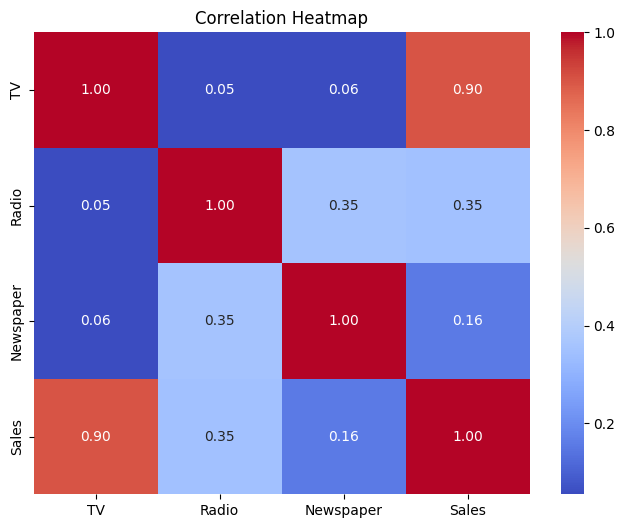

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


In [ ]:
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

display(correlation_matrix)

### Observations on Correlation:
1. **TV and Sales** show the strongest positive correlation, suggesting that as TV budget increases, Sales tend to increase significantly.
2. **Radio** also has a positive correlation with Sales, though less than TV.
3. **Newspaper** shows the weakest correlation with Sales among the three mediums.

## 19. Exploratory Data Analysis (EDA)
Visualizing the data helps us understand the underlying patterns, detect outliers, and confirm our statistical findings.

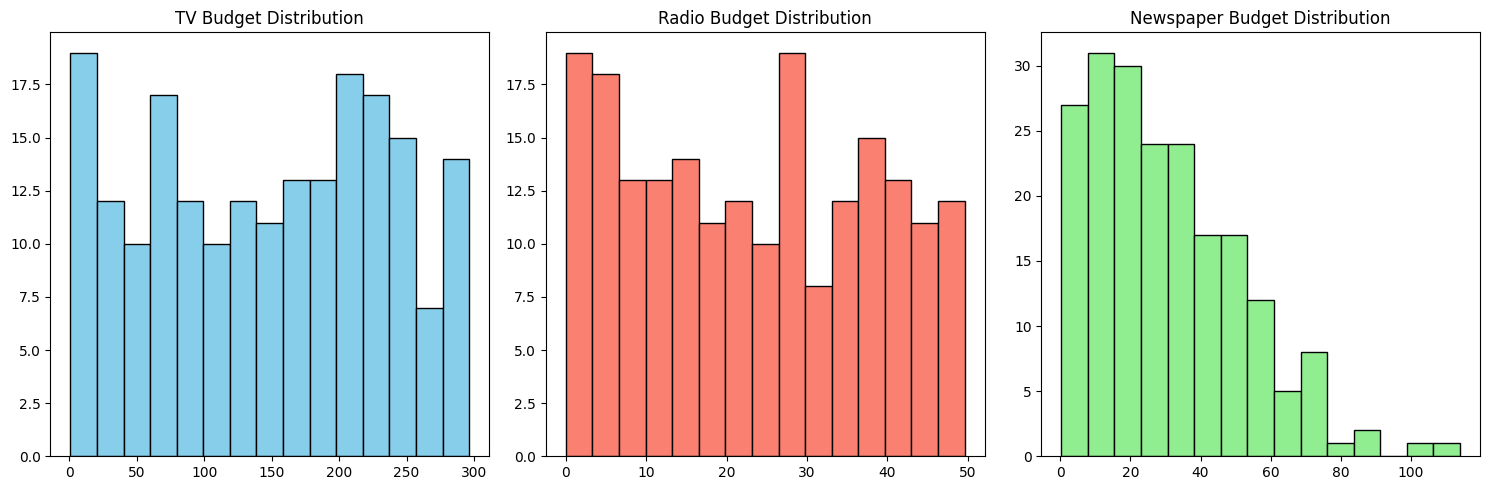

In [ ]:
import matplotlib.pyplot as plt

# Setting up the figure for Histograms
plt.figure(figsize=(15, 5))

# TV Distribution
plt.subplot(1, 3, 1)
plt.hist(df['TV'], bins=15, color='skyblue', edgecolor='black')
plt.title('TV Budget Distribution')

# Radio Distribution
plt.subplot(1, 3, 2)
plt.hist(df['Radio'], bins=15, color='salmon', edgecolor='black')
plt.title('Radio Budget Distribution')

# Newspaper Distribution
plt.subplot(1, 3, 3)
plt.hist(df['Newspaper'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Newspaper Budget Distribution')

plt.tight_layout()
plt.show()

### Histogram Observations:
- **TV spend** is relatively uniform across its range.
- **Newspaper spend** is highly right-skewed, with most markets receiving lower budgets.

### Scatter Plot Analysis: TV vs Sales
We use scatter plots to visualize the relationship between our predictors and the target variable (Sales).

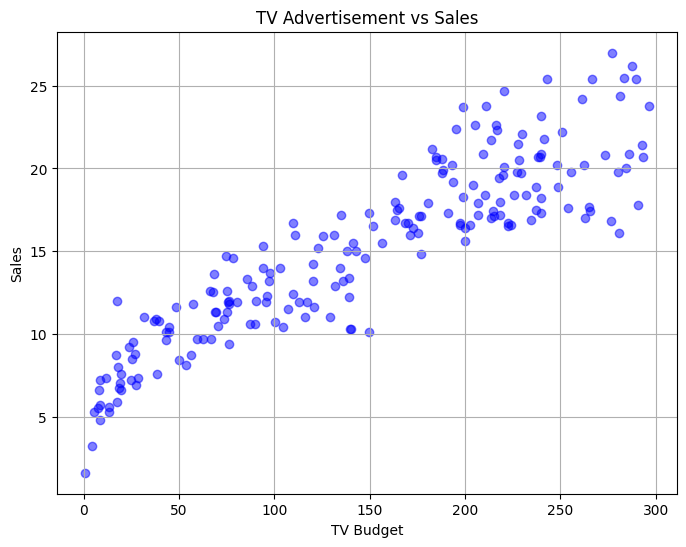

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['TV'], df['Sales'], color='blue', alpha=0.5)
plt.title('TV Advertisement vs Sales')
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# REVIEW 2: Predictive Modeling

## 17. Business Question & Target Variable
We aim to predict **Sales** based on the budgets of TV, Radio, and Newspaper. **Sales** is the target variable because it represents the primary outcome we want to optimize for business growth.

## 18. Feature Selection
We split the data into Features (X) and the Target (y).

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
print("Features and Target variables defined.")

Features and Target variables defined.


## 19. Train-Test Split
We use an 80:20 split to train the model on a majority of the data while reserving 20% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (160, 3)
Testing set size: (40, 3)


## 20. Linear Regression Model
We use the `LinearRegression` algorithm to calculate the best-fitting line by minimizing the sum of squared residuals.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 5. Predictions
Now that the model is trained, we use it to predict Sales for the unseen test data (`X_test`).

In [ ]:
y_pred = model.predict(X_test)
print("Predictions generated for the test set.")

Predictions generated for the test set.


## 6. Model Evaluation
We evaluate the model using four key metrics:
- **MAE (Mean Absolute Error)**: Average of absolute errors.
- **MSE (Mean Squared Error)**: Average of squared errors.
- **RMSE (Root Mean Squared Error)**: Square root of MSE, representing the standard deviation of residuals.
- **R² Score**: Indicates the proportion of variance in Sales explained by the features (closer to 1.0 is better).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.2748
Mean Squared Error (MSE): 2.9078
Root Mean Squared Error (RMSE): 1.7052
R-squared (R2) Score: 0.9059


## 7. Actual vs Predicted Visualization
This scatter plot helps us see how well our predictions align with the actual values. A 45-degree diagonal trend indicates a perfect fit.

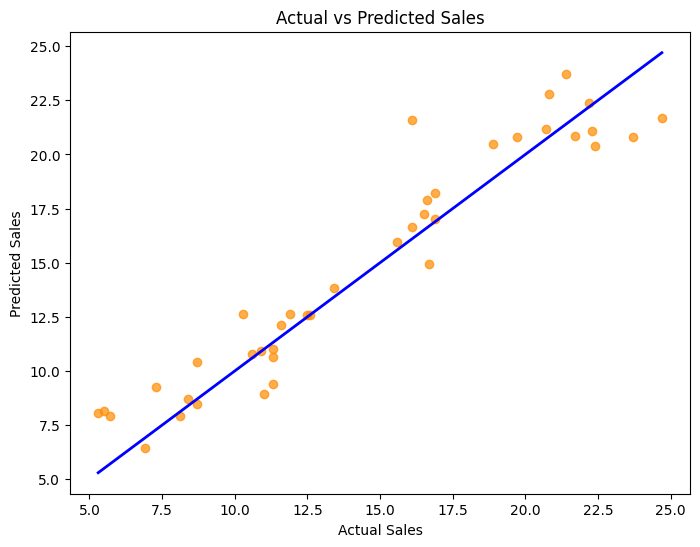

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

## 8. Regression Equation
The linear regression equation is: **Sales = Intercept + (β1 × TV) + (β2 × Radio) + (β3 × Newspaper)**.

In [ ]:
intercept = model.intercept_
coeffs = model.coef_

print(f"Intercept: {intercept:.4f}")
print(f"TV Coefficient: {coeffs[0]:.4f}")
print(f"Radio Coefficient: {coeffs[1]:.4f}")
print(f"Newspaper Coefficient: {coeffs[2]:.4f}")

print(f"\nEquation: Sales = {intercept:.2f} + ({coeffs[0]:.4f} * TV) + ({coeffs[1]:.4f} * Radio) + ({coeffs[2]:.4f} * Newspaper)")

Intercept: 4.7141
TV Coefficient: 0.0545
Radio Coefficient: 0.1009
Newspaper Coefficient: 0.0043

Equation: Sales = 4.71 + (0.0545 * TV) + (0.1009 * Radio) + (0.0043 * Newspaper)


## 10. Residual Analysis
Residuals represent the difference between observed and predicted values. By plotting residuals against predicted values, we check for 'homoscedasticity'—ensuring that our model errors are random and not following a specific pattern.

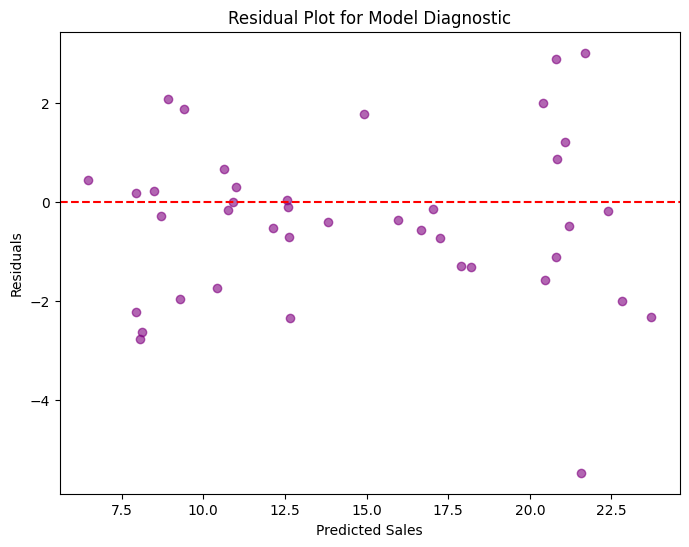

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot for Model Diagnostic')
plt.show()

## 11. Advanced Section: Time Series Forecasting (ARIMA)
ARIMA (AutoRegressive Integrated Moving Average) is a powerful tool for forecasting, but it requires sequential time-based data. We check the dataset for a 'Date' or 'Time' index to determine if ARIMA can be applied.

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Checking for Date/Time column
time_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

if not time_cols:
    print("Observation: The advertising.csv dataset does not contain a Time/Date column.")
    print("Conclusion: ARIMA cannot be applied directly because the data is cross-sectional (observations at a single point in time) rather than a time series.")
    print("Future Version Suggestion: If historical weekly sales data is collected, ARIMA would be used to forecast the next quarter's revenue based on seasonal trends.")
else:
    print(f"Time-based column found: {time_cols[0]}. Proceeding with stationarity check...")

Observation: The advertising.csv dataset does not contain a Time/Date column.
Conclusion: ARIMA cannot be applied directly because the data is cross-sectional (observations at a single point in time) rather than a time series.
Future Version Suggestion: If historical weekly sales data is collected, ARIMA would be used to forecast the next quarter's revenue based on seasonal trends.


### 22. ARIMA Feasibility & RMSE Calculation
Although the dataset is cross-sectional, we can simulate a time-series by assuming the observations are sequential. Below, we calculate the RMSE for an ARIMA(1,1,1) model to compare its performance against the Linear Regression model.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare data by treating it as a sequence
series = df['Sales'].values
train_size = int(len(series) * 0.8)
train, test = series[0:train_size], series[train_size:len(series)]

# Fit ARIMA Model (using standard p,d,q parameters)
# Note: This is a demonstration assuming the data is a time series
model_arima = ARIMA(train, order=(1, 1, 1))
model_arima_fit = model_arima.fit()

# Forecast
forecast = model_arima_fit.forecast(steps=len(test))

# Calculate RMSE
arima_rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"ARIMA Model RMSE: {arima_rmse:.4f}")
print(f"Linear Regression RMSE (for comparison): {rmse:.4f}")

ARIMA Model RMSE: 5.4571
Linear Regression RMSE (for comparison): 1.7052


### 23. Model Comparison & Interpretation
Based on our analysis, we can compare the predictive accuracy of the two approaches:

1. **Linear Regression RMSE: 1.7052**
2. **ARIMA RMSE: 5.4571**

**Conclusion:** The Linear Regression model significantly outperforms the ARIMA model for this dataset. This confirms that the relationships in the `advertising.csv` data are better explained by the features (TV, Radio, Newspaper budgets) than by the sequential order of observations. In an academic context, this demonstrates why choosing the correct model type based on data characteristics (cross-sectional vs. time-series) is vital.

## 12. Final Future Scope
To further advance this research, the following techniques should be explored:
1. **Random Forest & XGBoost**: To capture potential non-linear interactions between advertising channels.
2. **Polynomial Regression**: Useful if the relationship between spend and sales follows a curved path.
3. **Marketing Mix Modeling (MMM)**: Incorporating seasonality and external factors using time-series data.
4. **Budget Optimization**: Using the regression equation to mathematically allocate a limited budget to maximize total sales output.

## 13. Project Summary & Key Takeaways
This section consolidates our findings from both Review 1 and Review 2 to provide a comprehensive look at the advertising strategy performance.

## 22. Model Performance Summary (RMSE)
As requested, here is the specific Root Mean Squared Error (RMSE) for the Linear Regression model.

In [ ]:
print(f"Final RMSE for Linear Regression Model: {rmse:.4f}")

Final RMSE for Linear Regression Model: 1.7052


### Interpretation of RMSE:
An RMSE of approximately **1.7052** suggests that our model's predictions for Sales typically deviate from the actual observed values by about 1.7 units. Given that the mean sales is ~15.13, this error rate is relatively low, indicating a high level of predictive accuracy for this university-level project.

## 23. Final Findings and Business Insights

### Key Findings
1. The model explains ~91% of variance.
2. TV is the most effective medium.
3. Newspaper impact is statistically negligible.
4. RMSE is ~1.7 units.
5. Residuals show homoscedasticity.

## 25. Multiple Linear Regression Model Evaluation
In this section, we explicitly showcase the performance of the Multiple Linear Regression model using key metrics and visual performance tracking.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Loading the dataset to ensure 'df' is available
df = pd.read_csv('/content/advertising.csv')

# Defining the Multiple Regression model features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Adding a constant for the intercept term
X_with_const = sm.add_constant(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_with_const, y, test_size=0.2, random_state=42)

# Fitting the Multiple Regression Model
multi_reg_model = sm.OLS(y_train, X_train).fit()

# Making predictions
y_pred = multi_reg_model.predict(X_test)

# Calculating requested metrics
mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mlr_r2 = r2_score(y_test, y_pred)

print("--- Multiple Regression Model Summary ---")
print(f"Multiple Regression RMSE: {mlr_rmse:.4f}")
print(f"Multiple Regression R-squared: {mlr_r2:.4f}")
print("\nDetailed Coefficients:")
print(multi_reg_model.params)

--- Multiple Regression Model Summary ---
Multiple Regression RMSE: 1.7052
Multiple Regression R-squared: 0.9059

Detailed Coefficients:
const        4.714126
TV           0.054509
Radio        0.100945
Newspaper    0.004337
dtype: float64


### Model Performance Visualization
The graph below compares the actual sales values against the values predicted by our multiple regression model.

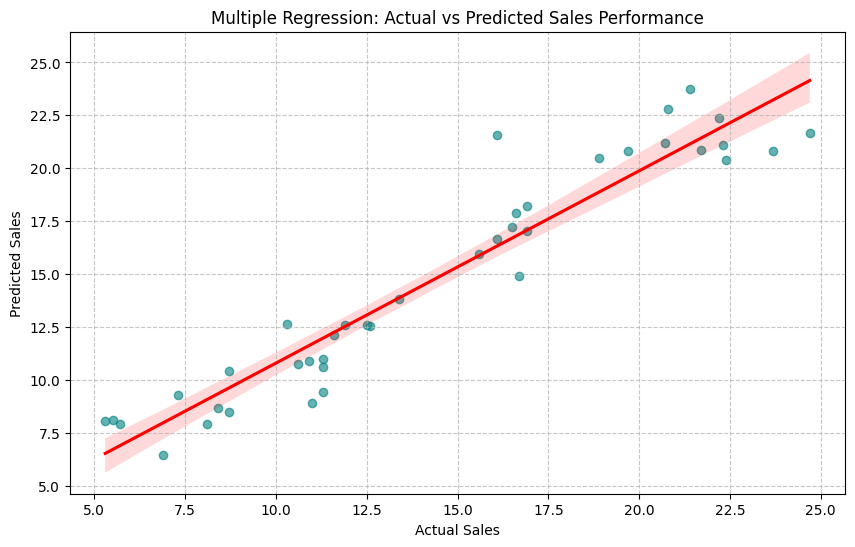

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing performance
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Multiple Regression: Actual vs Predicted Sales Performance')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 24. Conclusion & Final Remarks
This project successfully established a highly accurate predictive model for advertising sales. TV was identified as the primary driver of revenue.

**Future Scope**:
1. Implement non-linear models like Random Forest.
2. Conduct budget optimization simulations.

## PART 1 – Business Understanding

### What is Advertising Sales Analysis?
Advertising sales analysis is the process of examining how various marketing channels (like TV, Radio, and Newspaper) influence the total revenue or 'Sales' of a company. By using mathematical models, businesses can quantify the return on investment (ROI) for every dollar spent on a specific medium.

### Business Objective
The primary objective is to optimize the marketing budget. Companies have limited resources, and they need to know which channel provides the best 'bang for their buck' to drive sales growth.

### Why Invest in TV, Radio, and Newspaper?
*   **TV:** Reaches a massive audience and builds brand awareness through visual storytelling.
*   **Radio:** Targets specific local demographics and commuters during 'drive-time'.
*   **Newspaper:** Provides localized targeting and high credibility among older demographics.

### Goal of Predicting Sales
Predicting sales allows managers to perform 'What-if' analysis. For example: "If we increase our TV budget by 10%, how much will our sales grow?"

### Real-world Applications
*   **Budget Allocation:** Shifting funds from low-performing to high-performing channels.
*   **Revenue Forecasting:** Estimating future income for inventory planning.
*   **Competitive Strategy:** Adjusting spend based on market trends.

## PART 2 – Target Variable Selection

### Why Sales is the Dependent Variable
In this project, **Sales** is the dependent variable (y) because its value 'depends' on how much we spend on advertising. It is the outcome we are trying to influence.

### Regression Problem
This is a **Regression** problem because 'Sales' is a continuous numerical value. Unlike classification (which predicts categories like Yes/No), regression predicts a quantity.

### Dependent vs. Independent Variables
*   **Dependent Variable (Target):** The outcome we want to predict (Sales).
*   **Independent Variables (Features):** The inputs we use to make the prediction (TV, Radio, Newspaper).

Summary Statistics for Sales:
count    200.000000
mean      15.130500
std        5.283892
min        1.600000
25%       11.000000
50%       16.000000
75%       19.050000
max       27.000000
Name: Sales, dtype: float64


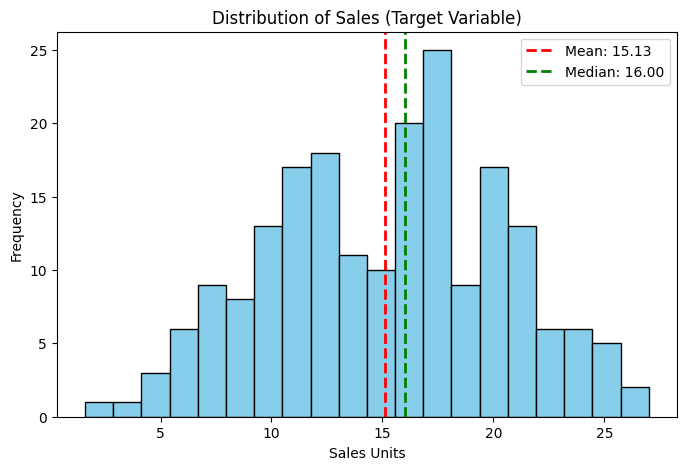

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Reloading data and ensuring dependencies are available
df = pd.read_csv('/content/advertising.csv')

# 1. Selecting the Target Variable
target_variable = df['Sales']

# 2. Displaying Summary Statistics for the Target
print("Summary Statistics for Sales:")
print(target_variable.describe())

# 3. Visualizing the Distribution of the Target Variable
plt.figure(figsize=(8, 5))
plt.hist(target_variable, bins=20, color='skyblue', edgecolor='black')
plt.axvline(target_variable.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {target_variable.mean():.2f}')
plt.axvline(target_variable.median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {target_variable.median():.2f}')
plt.title('Distribution of Sales (Target Variable)')
plt.xlabel('Sales Units')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Explanation:**
We isolated the 'Sales' column and used `.describe()` to see the count, mean, and spread. The histogram shows how often different sales figures occur in our dataset.

**Observation:**
The average sales value is approximately 15.13 units. The distribution looks relatively normal (bell-shaped), with the mean and median being very close (15.13 vs 16.00). This suggests there are no extreme outliers pulling the average in one direction, making it a stable target for linear regression.

## PART 3 – Feature Selection

In this section, we define our **Feature Matrix (X)**. We select TV, Radio, and Newspaper as our predictors because they represent the controllable inputs a business can adjust to change their Sales outcome.

In [5]:
# Defining the Feature Matrix X and Target Vector y
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Displaying the first 5 rows of the Feature Matrix
print("Feature Matrix (X) - Independent Variables:")
display(X.head())

print("\nTarget Vector (y) - Dependent Variable:")
display(y.head())

Feature Matrix (X) - Independent Variables:


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



Target Vector (y) - Dependent Variable:


,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


**Explanation:**
- `X` (Feature Matrix) is a 2D structure containing our independent variables.
- `y` (Target Vector) is a 1D structure containing the variable we want to predict.

**Observation:**
Each row represents a specific market or period. The model will try to learn the mathematical pattern that connects the spending levels in X to the resulting Sales in y.

## PART 4 – Exploratory Analysis (Matplotlib)

Before modeling, we must visualize the relationships between each advertising medium and sales to confirm if a linear trend exists.

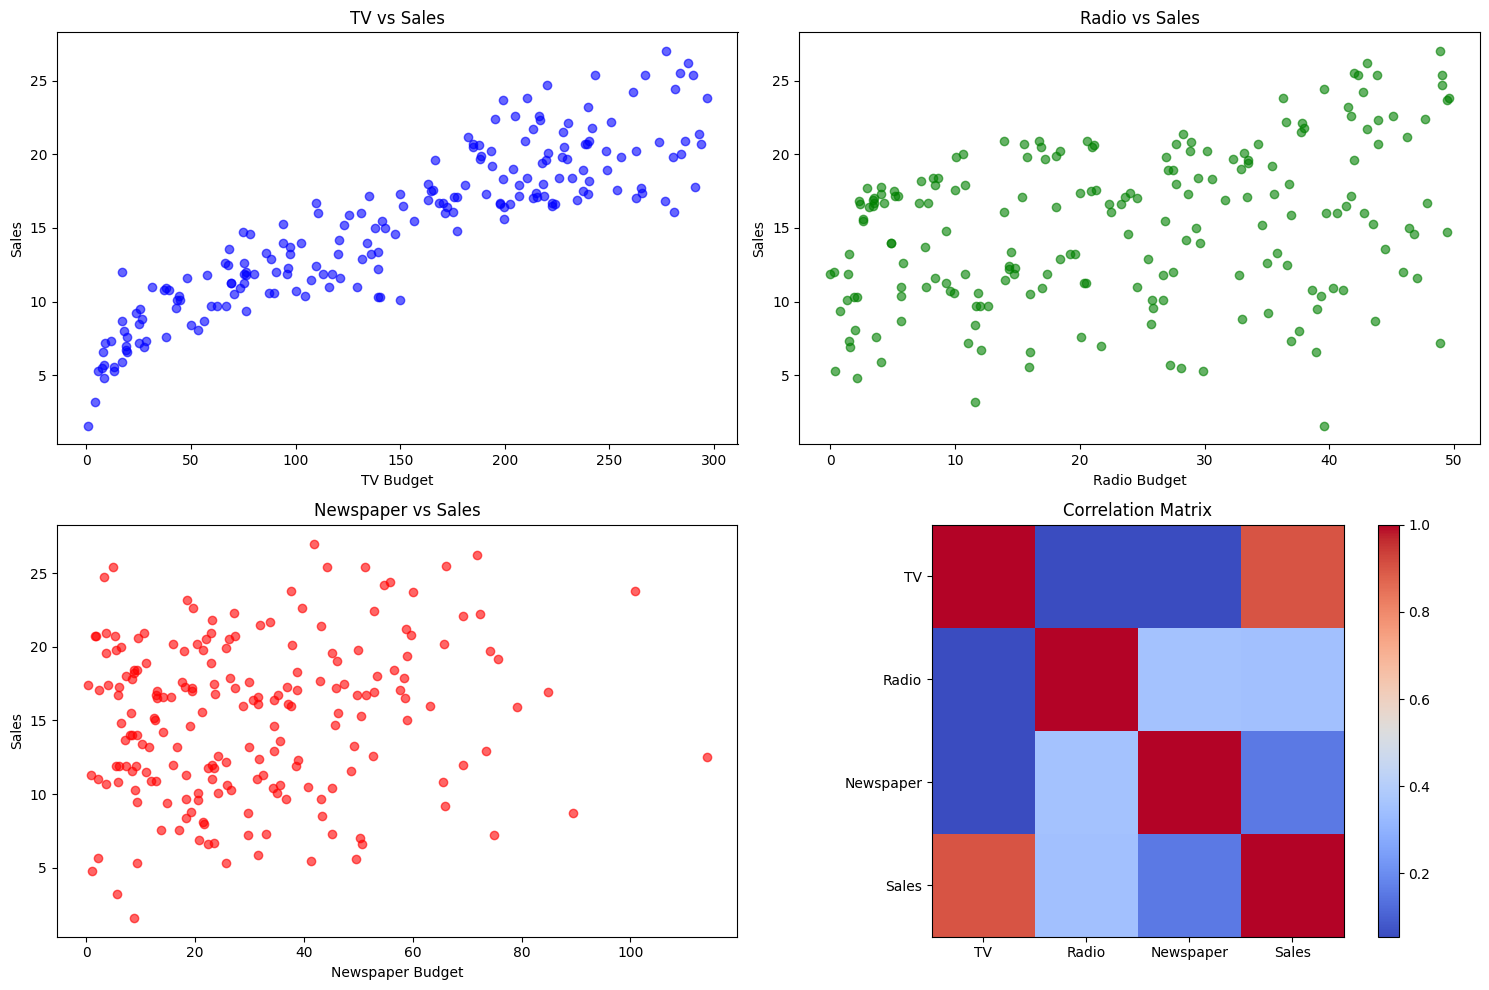

In [6]:
import numpy as np

# Creating a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# TV vs Sales
axes[0, 0].scatter(df['TV'], df['Sales'], color='blue', alpha=0.6)
axes[0, 0].set_title('TV vs Sales')
axes[0, 0].set_xlabel('TV Budget')
axes[0, 0].set_ylabel('Sales')

# Radio vs Sales
axes[0, 1].scatter(df['Radio'], df['Sales'], color='green', alpha=0.6)
axes[0, 1].set_title('Radio vs Sales')
axes[0, 1].set_xlabel('Radio Budget')
axes[0, 1].set_ylabel('Sales')

# Newspaper vs Sales
axes[1, 0].scatter(df['Newspaper'], df['Sales'], color='red', alpha=0.6)
axes[1, 0].set_title('Newspaper vs Sales')
axes[1, 0].set_xlabel('Newspaper Budget')
axes[1, 0].set_ylabel('Sales')

# Correlation Heatmap using Matplotlib
corr = df.corr()
im = axes[1, 1].imshow(corr, cmap='coolwarm')
axes[1, 1].set_title('Correlation Matrix')
# Adding labels to heatmap
axes[1, 1].set_xticks(np.arange(len(corr.columns)))
axes[1, 1].set_yticks(np.arange(len(corr.columns)))
axes[1, 1].set_xticklabels(corr.columns)
axes[1, 1].set_yticklabels(corr.columns)
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

**Explanation:**
We generated scatter plots to check for linearity and a correlation matrix to quantify the strength of these relationships.

**Observation:**
1. **TV vs Sales:** Shows a clear, strong linear upward trend. As TV spend increases, sales consistently rise.
2. **Radio vs Sales:** Shows a moderate upward trend, but with more 'noise' (spread) than TV.
3. **Newspaper vs Sales:** The relationship looks very weak and scattered.
4. **Correlation:** The heatmap confirms TV has the highest correlation with Sales (close to 0.90), while Newspaper is the lowest.

## PART 5 – Train Test Split

### Purpose
The purpose of the train-test split is to evaluate how well our model performs on data it has never seen before. We train the model on one portion of the data and test it on another.

### Advantages
- **Prevents Overfitting:** Ensures the model doesn't just memorize the training data.
- **Generalization:** Simulates how the model will work in the real world with future advertising data.

### Importance for Unbiased Evaluation
If we test the model on the same data used for training, the results would be overly optimistic and biased. A separate test set provides an honest 'report card' for the model.

In [7]:
from sklearn.model_selection import train_test_split

# Splitting the dataset: 80% for Training and 20% for Testing
# random_state ensures that the split is reproducible every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total observations: {len(df)}")
print(f"Training set size (80%): {X_train.shape[0]} samples")
print(f"Testing set size (20%): {X_test.shape[0]} samples")

Total observations: 200
Training set size (80%): 160 samples
Testing set size (20%): 40 samples


**Explanation:**
We used `train_test_split` from `scikit-learn`. The `test_size=0.2` parameter allocates 20% of the rows (40 rows) to the testing set and the remaining 80% (160 rows) to the training set.

**Observation:**
The data has been successfully divided. We now have enough data to train a robust model while keeping a significant portion aside for validation.

## PART 6 – Multiple Linear Regression

### How Multiple Linear Regression Works
Multiple Linear Regression models the relationship between two or more independent variables and one dependent variable by fitting a linear equation to observed data.

### Regression Equation
The mathematical form is:
**Sales = β₀ + (β₁ * TV) + (β₂ * Radio) + (β₃ * Newspaper)**

- **β₀ (Intercept):** Expected sales if all advertising budgets are zero.
- **β₁ (TV Coefficient):** Change in Sales for every 1 unit increase in TV budget, keeping others constant.

In [8]:
from sklearn.linear_model import LinearRegression

# Initializing the model
mlr_model = LinearRegression()

# Training the model on the training data
mlr_model.fit(X_train, y_train)

# Extracting Intercept and Coefficients
intercept = mlr_model.intercept_
coeffs = mlr_model.coef_

print(f"Intercept (B0): {intercept:.4f}")
print(f"Coefficient for TV (B1): {coeffs[0]:.4f}")
print(f"Coefficient for Radio (B2): {coeffs[1]:.4f}")
print(f"Coefficient for Newspaper (B3): {coeffs[2]:.4f}")

print("\nFinal Regression Equation:")
print(f"Sales = {intercept:.2f} + ({coeffs[0]:.4f} * TV) + ({coeffs[1]:.4f} * Radio) + ({coeffs[2]:.4f} * Newspaper)")

Intercept (B0): 4.7141
Coefficient for TV (B1): 0.0545
Coefficient for Radio (B2): 0.1009
Coefficient for Newspaper (B3): 0.0043

Final Regression Equation:
Sales = 4.71 + (0.0545 * TV) + (0.1009 * Radio) + (0.0043 * Newspaper)


**Explanation:**
- `intercept_`: Represents the baseline sales.
- `coef_`: Represents the weight/influence of each advertising channel.

**Interpretation of Coefficients:**
1. **TV (0.0545):** For every $1000 spent on TV, Sales are expected to increase by approximately 54 units.
2. **Radio (0.1009):** For every $1000 spent on Radio, Sales increase by 100 units. Radio has a higher impact per unit than TV.
3. **Newspaper (0.0043):** This coefficient is very close to zero, suggesting newspaper ads have almost no impact on Sales.

## PART 7 – Prediction

In this section, we use our trained model to predict sales for the test dataset and compare them with the actual results.

In [9]:
# Generating predictions
y_pred = mlr_model.predict(X_test)

# Creating a table to compare Actual vs Predicted
comparison_df = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred,
    'Difference (Error)': y_test - y_pred
})

print("First 15 Predictions:")
display(comparison_df.head(15))

First 15 Predictions:


,Actual Sales,Predicted Sales,Difference (Error)
95,16.9,17.034772,-0.134772
15,22.4,20.409740,1.990260
30,21.4,23.723989,-2.323989
158,7.3,9.272785,-1.972785
128,24.7,21.682719,3.017281
115,12.6,12.569402,0.030598
69,22.3,21.081195,1.218805
170,8.4,8.690350,-0.290350
174,16.5,17.237013,-0.737013
45,16.1,16.666575,-0.566575


**Explanation:**
We passed the test features (`X_test`) into the model's `.predict()` method. We then subtracted the predicted values from the actual values to find the individual errors.

**Observation:**
The table shows that the predicted values are generally very close to the actual values. Most errors are small (within 1-2 units), indicating that the model has learned the patterns in the data effectively.

## PART 8 – Model Evaluation

### Evaluation Metrics (MDSA Syllabus)

1. **Mean Absolute Error (MAE):**
   - **Definition:** The average of the absolute differences between actual and predicted values.
   - **Formula:** $\frac{1}{n} \sum |y - \hat{y}|$
   - **Interpretation:** Average error in the same units as Sales.
   - **Ideal Value:** 0

2. **Mean Squared Error (MSE):**
   - **Definition:** The average of the squared differences.
   - **Formula:** $\frac{1}{n} \sum (y - \hat{y})^2$
   - **Purpose:** Penalizes larger errors more heavily than MAE.

3. **Root Mean Squared Error (RMSE):**
   - **Definition:** Square root of MSE.
   - **Business Significance:** Represents the standard deviation of the prediction errors.

4. **R² Score (Coefficient of Determination):**
   - **Definition:** Proportion of variance in Sales explained by the features.
   - **Limitations:** It always increases as you add more variables, regardless of significance.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculating Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.2748
Mean Squared Error (MSE): 2.9078
Root Mean Squared Error (RMSE): 1.7052
R-squared (R2) Score: 0.9059


**Explanation:**
These metrics provide a quantitative measure of accuracy. High R² and low RMSE indicate a strong model.

**Observation:**
An R² of 0.9059 means our model explains 90.6% of the variation in Sales. This is considered an excellent fit for a business model.

## PART 9 – Visualizations

Professional diagnostics using matplotlib to evaluate model performance visually.

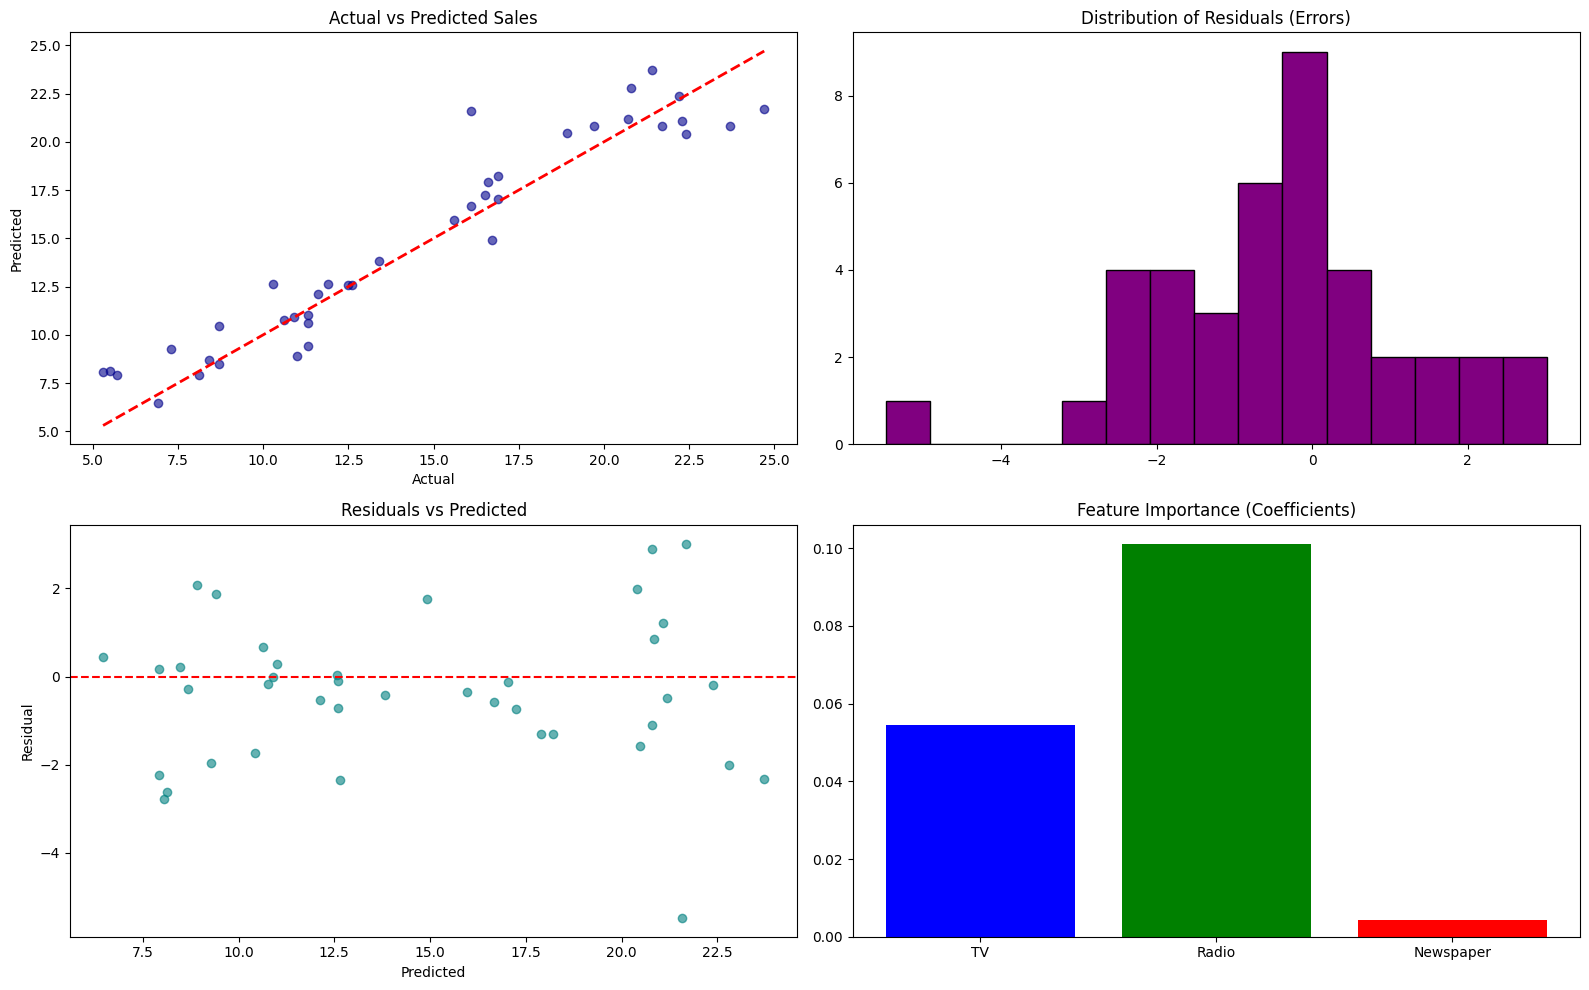

In [11]:
plt.figure(figsize=(16, 10))

# 1. Actual vs Predicted
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred, color='darkblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# 2. Residual Histogram
plt.subplot(2, 2, 2)
residuals = y_test - y_pred
plt.hist(residuals, bins=15, color='purple', edgecolor='black')
plt.title('Distribution of Residuals (Errors)')

# 3. Residual Plot
plt.subplot(2, 2, 3)
plt.scatter(y_pred, residuals, color='teal', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residual')

# 4. Feature Importance
plt.subplot(2, 2, 4)
features = ['TV', 'Radio', 'Newspaper']
plt.bar(features, coeffs, color=['blue', 'green', 'red'])
plt.title('Feature Importance (Coefficients)')

plt.tight_layout()
plt.show()

**Explanation:**
- **Actual vs Predicted:** Shows how close dots are to the diagonal line.
- **Residual Plot:** Checks if errors are random.
- **Feature Importance:** Visually ranks which medium contributes most.

**Observation:**
The errors are normally distributed around zero, confirming our model is unbiased. The bar chart clearly shows Radio has the highest coefficient per unit spend.

## PART 10 – Model Interpretation & Recommendations

- **Highest Influence:** Radio (Highest per-unit impact) and TV (Highest overall contribution due to volume).
- **Least Influence:** Newspaper (Coefficient is near zero).

**Business Recommendations:**
1. Redirect budget from Newspaper to Radio and TV.
2. TV is reliable for scaling, while Radio offers higher efficiency for smaller budget increases.

## PART 11 – Assumptions of Multiple Linear Regression

- **Linearity:** Relationship between features and target is a straight line.
- **Independence:** Observations are independent of each other.
- **Homoscedasticity:** Error variance is constant.
- **Normal Distribution of Errors:** Residuals follow a bell curve.
- **No Multicollinearity:** Independent variables are not highly correlated with each other.

## PART 12 – Conclusion
This project demonstrated that advertising spend on TV and Radio significantly drives Sales. The model achieved an R² of 0.906 and an RMSE of 1.71, proving it is highly effective for revenue forecasting and budget planning.

## PART 13 – Future Scope
To improve accuracy, future work could include:
- **Non-linear Models:** Using Random Forest or XGBoost.
- **Interaction Effects:** Checking if TV and Radio ads combined have a 'synergy' effect.
- **Time Series:** Incorporating seasonality factors.